Notebook for illustrating the optimizations done in the gradient computation on the restricted state space.

In [1]:
import mhn
from mhn.optimizers import Optimizer, Device
import pandas as pd
import time
import matplotlib.pyplot as plt
import math
import numpy as np

np.random.seed(123)


/home/mbonart/learnmhn/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For performance evaluation we are interested in whether CUDA optimizations are available on our machine

In [2]:
mhn.CUDA_AVAILABLE

'CUDA is available'

In [3]:
opt = Optimizer()
opt.set_penalty(opt.Penalty.L1)
opt.set_device(Device.GPU)

In [4]:
input = pd.read_csv('LUAD_n12.csv')

/home/mbonart/learnmhn/mhn/optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


[477, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

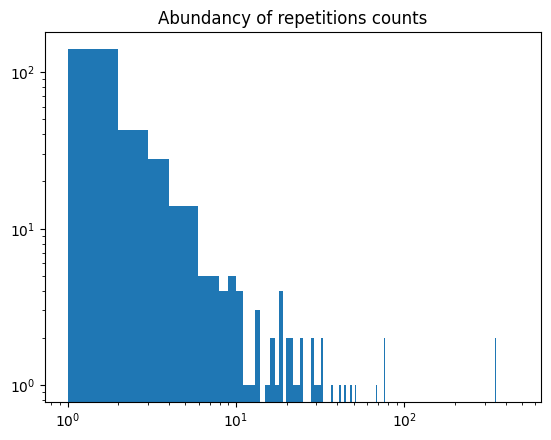

In [5]:
my_data = np.tile(input, (1,1))
opt.load_data_matrix(my_data)
repetitions=opt._data.get_repetition_descriptor()
print(repetitions)
print(sum(repetitions))
print(f"{sum([1 if r==0 else 0 for r in repetitions])} / {len(my_data)} are redundant samples")
plt.hist([r for r in repetitions if r!=0], bins=max(repetitions),)
plt.yscale('log')
plt.xscale('log')
plt.title("Abundancy of repetitions counts")
plt.show()

In [ ]:
#test code
opt._data.compress_data()
compr_repetitions = opt._data.get_repetition_descriptor()
print(repetitions)
print(compr_repetitions)
print(f"{len(compr_repetitions)} unique samples")

[477, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [7]:
print(opt._data.get_max_mutation_num())

6


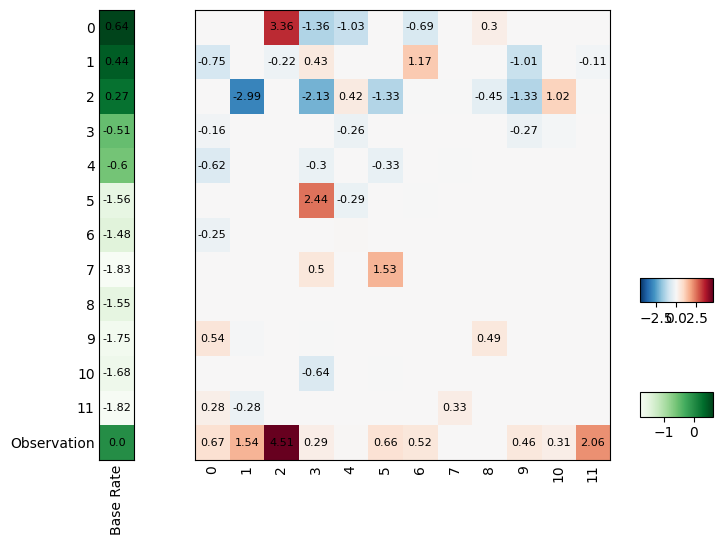

In [8]:
opt.train(5/len(input))
opt.result.plot()
plt.show()

In [9]:
import gc

In [10]:
dataset_fractions = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9]
N=len(input)
computation_speeds={frac:[] for frac in dataset_fractions}
max_it = 200

repetitions=3
for i in range(repetitions):
    for dataset_fraction in dataset_fractions:
        input_subset = np.tile(input, (math.ceil(dataset_fraction),1))[:int(N*dataset_fraction)]
        

        #input_subset = input.sample(frac=dataset_fraction, replace=True, random_state=6)
        start_prep = time.process_time()
        opt.load_data_matrix(input_subset)
        opt._data.compress_data()
        end_prep = time.process_time()


        print(f"{dataset_fraction} fraction of dataset ({len(input_subset)}) ")

        start_coll = time.process_time()
        gc.collect()
        end_coll = time.process_time()
        print(f"Garbage collection time: {end_coll-start_coll}")

        #measure time optimization takes
        start = time.process_time()
    
        opt.train(maxit=max_it)      
        end = time.process_time()

        time_elapsed= end-start
        computation_speeds[dataset_fraction].append(time_elapsed)
        print(f"Preparation time: {end_prep-start_prep}\t CPU time: {time_elapsed} seconds")

/home/mbonart/learnmhn/mhn/optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


0.1 fraction of dataset (366) 
Garbage collection time: 0.12692529000000263
Preparation time: 0.001221607000005065	 CPU time: 10.624414705 seconds
0.25 fraction of dataset (915) 
Garbage collection time: 0.06320646100000005
Preparation time: 0.0014623369999995361	 CPU time: 18.576594147 seconds
0.5 fraction of dataset (1831) 
Garbage collection time: 0.0848923390000067
Preparation time: 0.003573463999998694	 CPU time: 27.109034777000005 seconds
0.75 fraction of dataset (2746) 
Garbage collection time: 0.08711863700000322
Preparation time: 0.004310470999996596	 CPU time: 32.69063644799999 seconds
1 fraction of dataset (3662) 
Garbage collection time: 0.08607355199998779
Preparation time: 0.005288603999986208	 CPU time: 37.06431464299999 seconds
1.5 fraction of dataset (5493) 
Garbage collection time: 0.06394476899998836
Preparation time: 0.006418725999992603	 CPU time: 36.076683151 seconds
2 fraction of dataset (7324) 
Garbage collection time: 0.08387380300001723
Preparation time: 0.008

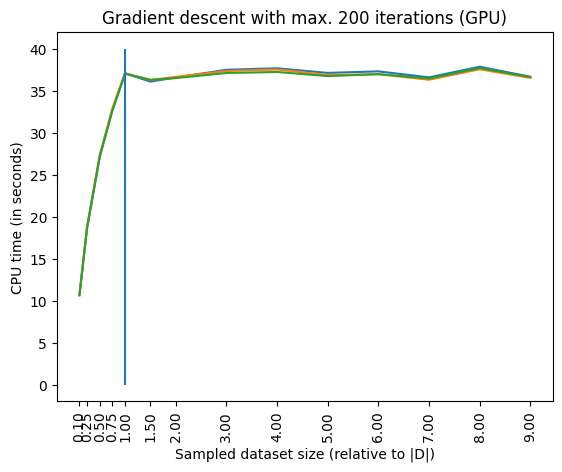

In [13]:
comp_speeds_df=pd.DataFrame.from_dict(computation_speeds)
comp_speeds_df.T.plot(xlabel="Sampled dataset size (relative to |D|)", ylabel="CPU time (in seconds)", xticks=dataset_fractions, legend=False)
plt.xticks(rotation=90)
plt.title(f"Gradient descent with max. {max_it} iterations (GPU)")

plt.vlines(1,0,40)

In [ ]:


dataset_fractions = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
N=len(input)
computation_times={frac:[] for frac in dataset_fractions}

repetitions=3
for i in range(repetitions):
    for dataset_fraction in dataset_fractions:
        input_subset = np.tile(input, (math.ceil(dataset_fraction),1))[:int(N*dataset_fraction)]
        

        #input_subset = input.sample(frac=dataset_fraction, replace=True, random_state=6)
        start_prep = time.process_time()
        opt.load_data_matrix(input_subset)
        opt._data.compress_data()
        end_prep = time.process_time()


        print(f"{dataset_fraction} fraction of dataset ({len(input_subset)}) ")

        start_coll = time.process_time()
        gc.collect()
        end_coll = time.process_time()
        print(f"Garbage collection time: {end_coll-start_coll}")

        #measure time optimization takes
        start = time.process_time()
        
        my_lam = 1.0/len(input_subset)
        if dataset_fraction > 1:
            my_lam = 1.0/N  # fix one value for lambda to have comparable score landscapes (for "full" datasets)
        opt.train(lam = my_lam)      
        end = time.process_time()

        time_elapsed= end-start
        computation_times[dataset_fraction].append(time_elapsed)
        print(f"Preparation time: {end_prep-start_prep}\t CPU time: {time_elapsed} seconds")

/home/mbonart/learnmhn/mhn/optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


0.1 fraction of dataset (366) 
Garbage collection time: 0.09402422700000024
Preparation time: 0.0008052910000007074	 CPU time: 0.4910940659999987 seconds
0.25 fraction of dataset (915) 
Garbage collection time: 0.0563365289999993
Preparation time: 0.0014010320000004128	 CPU time: 0.7875675849999997 seconds
0.5 fraction of dataset (1831) 
Garbage collection time: 0.05482876099999956
Preparation time: 0.002451319000000396	 CPU time: 1.091174336 seconds
0.75 fraction of dataset (2746) 
Garbage collection time: 0.06703283499999912
Preparation time: 0.0038760760000009498	 CPU time: 1.5845821999999998 seconds
1 fraction of dataset (3662) 
Garbage collection time: 0.056557257999998
Preparation time: 0.004483363999998602	 CPU time: 1.9349360669999989 seconds
1.5 fraction of dataset (5493) 
Garbage collection time: 0.06080730999999773
Preparation time: 0.006022551000000931	 CPU time: 1.3823110520000021 seconds
2 fraction of dataset (7324) 
Garbage collection time: 0.05832501200000095
Preparatio

In [ ]:
comp_times_df=pd.DataFrame.from_dict(computation_times)

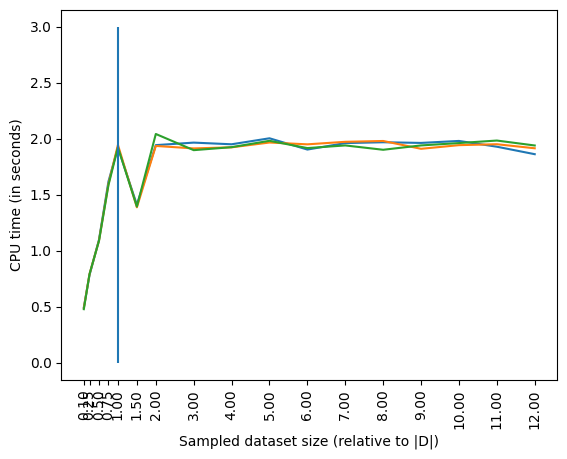

In [ ]:
comp_times_df.T.plot(xlabel="Sampled dataset size (relative to |D|)", ylabel="CPU time (in seconds)", xticks=dataset_fractions, legend=False)
plt.xticks(rotation=90)

plt.vlines(1,0,3)

In [ ]:
print(comp_times_df)

      0.10      0.25      0.50      0.75      1.00      1.50      2.00   \
0  0.494077  0.783229  1.098355  1.618444  1.921605  1.410873  1.943528   
1  0.489481  0.791370  1.090993  1.595798  1.945840  1.388207  1.936255   
2  0.478695  0.791844  1.088117  1.586551  1.924099  1.394684  2.043061   

      3.00      4.00      5.00      6.00      7.00      8.00      9.00   \
0  1.965944  1.951054  2.004562  1.903878  1.961763  1.969165  1.963189   
1  1.914120  1.923900  1.966756  1.950543  1.973122  1.980490  1.910644   
2  1.898503  1.925321  1.982032  1.917133  1.940741  1.902018  1.940850   

      10.00     11.00     12.00  
0  1.980937  1.929321  1.862559  
1  1.943241  1.951487  1.915411  
2  1.961924  1.984413  1.940262  


In [ ]:
print(opt._data.get_repetition_descriptor())

[5724, 2820, 4188, 2412, 4188, 4896, 12, 12, 336, 336, 912, 288, 12, 24, 372, 180, 816, 216, 912, 348, 24, 24, 36, 192, 60, 384, 252, 108, 48, 444, 264, 576, 120, 12, 24, 48, 12, 48, 108, 12, 12, 120, 96, 612, 108, 84, 60, 12, 36, 36, 240, 12, 48, 204, 48, 48, 24, 12, 12, 24, 84, 24, 12, 12, 24, 48, 252, 72, 96, 108, 144, 60, 72, 72, 12, 12, 36, 24, 24, 72, 60, 120, 12, 60, 36, 288, 12, 12, 12, 24, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 96, 216, 192, 240, 48, 120, 12, 36, 60, 60, 24, 12, 12, 36, 84, 48, 12, 36, 12, 72, 36, 12, 12, 36, 48, 12, 12, 12, 36, 24, 12, 12, 36, 12, 12, 12, 12, 12, 24, 12, 12, 24, 12, 12, 216, 492, 132, 156, 36, 24, 24, 24, 12, 12, 96, 60, 24, 12, 12, 24, 36, 12, 84, 48, 24, 12, 12, 36, 12, 24, 12, 12, 36, 24, 12, 12, 12, 12, 24, 12, 12, 12, 24, 60, 24, 24, 12, 36, 12, 36, 12, 24, 12, 12, 24, 12, 12, 12, 60, 156, 216, 156, 384, 276, 12, 12, 12, 60, 48, 36, 36, 60, 24, 12, 12, 12, 24, 12, 12, 12, 24, 12, 12, 24, 12, 12, 12, 12, 24, 24, 12, 12, 12, 12, 12, 36, 2